# User guide notebook - Pipeline from H2O models

<strong>This notebook presents the usage of the pipelines assuming you have already trained and saved your H2O models and necessary datasets. If that is not true for you, please train and save H2O models first.</strong>

<span style="color:orange">NOTE 1 : </span> It is crucial to stratify your data while performing the train test split, so that there are no classes in test data that were not present in the train set. <br>
<span style="color:orange">NOTE 2 : </span> It is crucial to convert binary target column labels into 0 for negative class and 1 for positive class. Otherwise, some evaluation metrics may not be calculated correctly.

In [1]:
import pandas as pd
from pathlib import Path
import pickle
import sys
import h2o
from h2o.frame import H2OFrame
from sklearn.model_selection import train_test_split
BASE_DIR = Path.cwd()
import os
project_root = BASE_DIR.parent
src_path = project_root/"src"
sys.path.append(str(src_path))

#make sure the Project root directory is correct [...]/Rashomon_analysis
print(BASE_DIR.parent)

from arsa_ml.pipelines.builder_abstract import *
from arsa_ml.pipelines.pipelines_user_input import *

C:\Users\rogal\MojGithub\ARSA-Automated-Rashomon-Set-Analysis


C:\Users\rogal\AppData\Local\pypoetry\Cache\virtualenvs\rashomon-analysis-n5ZWqiM8-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make sure to provide a correct path to the Java installed on your device !
os.environ["JAVA_HOME"] = "C:\\Program Files\\Java\\jdk-17"
os.environ["PATH"] = "C:\\Program Files\\Java\\jdk-17\\bin;" + os.environ["PATH"]

## Build Rashomon Set pipeline from H2O input

## Provide all necessary arguments:
all you need to initizalize the pipeline is path to folder with your H2O models and test data as h2o.frame.H2OFrame object

In [3]:
#provide test data argument
data = pd.read_csv(project_root/"demo_data"/"heart.csv")
target_column = 'HeartDisease'
train, test = train_test_split(data, test_size=0.2, random_state=42, stratify=data[target_column])
h2o.init()
train_h2o = h2o.H2OFrame(train)
test_h2o = h2o.H2OFrame(test)
train_h2o[target_column] = train_h2o[target_column].asfactor()
test_h2o[target_column] = test_h2o[target_column].asfactor()


#provide models path argument:
example_models_path = project_root / "demo_models" /"h2o" /"heart"
#verify the correctness of the path
print(example_models_path)
print(type(test_h2o))

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)
  Starting server from C:\Users\rogal\AppData\Local\pypoetry\Cache\virtualenvs\rashomon-analysis-n5ZWqiM8-py3.11\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\rogal\AppData\Local\Temp\tmp6m8h1mlr
  JVM stdout: C:\Users\rogal\AppData\Local\Temp\tmp6m8h1mlr\h2o_rogal_started_from_python.out
  JVM stderr: C:\Users\rogal\AppData\Local\Temp\tmp6m8h1mlr\h2o_rogal_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Warsaw
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,11 months and 19 days
H2O_cluster_name:,H2O_from_python_rogal_ggcraq
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.938 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
C:\Users\rogal\MojGithub\ARSA-Automated-Rashomon-Set-Analysis\demo_models\h2o\heart
<class 'h2o.frame.H2OFrame'>


## Build pipeline

In [4]:
builder = BuildRashomonH2O(models_directory=example_models_path, 
                           test_data = test_h2o, 
                           target_column=target_column, 
                           df_name = 'heart', 
                           base_metric='precision', 
                           feature_imp_needed=True)

Converting H2O models to Rashomon Analysis format...
Converter results will be stored in: C:\Users\rogal\MojGithub\ARSA-Automated-Rashomon-Set-Analysis\demo_models\h2o\converter_results\heart_2026-03-19_15-14-06
Please wait...
This process may take several minutes depending on the number of models and dataset size.
If you wish to speed up the process, consider setting feature_imp_needed=False.


deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |████████████████████████

Conversion completed.
You can preview the Rashomon Set size plot using preview_rashomon() method to determine epsilon parameter value.


Model StackedEnsemble_AllModels_1_AutoML_2_20251028_151348 does not have .varimp(). None inserted.
Model StackedEnsemble_BestOfFamily_1_AutoML_2_20251028_151348 does not have .varimp(). None inserted.
H2O conversion results saved to: C:\Users\rogal\MojGithub\ARSA-Automated-Rashomon-Set-Analysis\demo_models\h2o\converter_results\heart_2026-03-19_15-14-06


## Preview Rashomon Set properties

To better understand the impact of the Epsilon parameter, run the preview_rashomon() before setting the Epsilon value. 

The Visualizer received a leaderboard displayed below.
Check if this is the desired leaderboard for analysis, else change the given Path parameter
                                                model  accuracy  \
0             DeepLearning_1_AutoML_2_20251028_151348  0.880435   
1   DeepLearning_grid_1_AutoML_2_20251028_151348_m...  0.907609   
2   DeepLearning_grid_1_AutoML_2_20251028_151348_m...  0.907609   
3   DeepLearning_grid_2_AutoML_2_20251028_151348_m...  0.902174   
4   DeepLearning_grid_2_AutoML_2_20251028_151348_m...  0.853261   
5   DeepLearning_grid_3_AutoML_2_20251028_151348_m...  0.907609   
6   DeepLearning_grid_3_AutoML_2_20251028_151348_m...  0.902174   
7                      DRF_1_AutoML_2_20251028_151348  0.864130   
8                      GBM_1_AutoML_2_20251028_151348  0.896739   
9                      GBM_2_AutoML_2_20251028_151348  0.869565   
10                     GBM_3_AutoML_2_20251028_151348  0.880435   
11                     GBM_4_AutoML_2_20251028_15

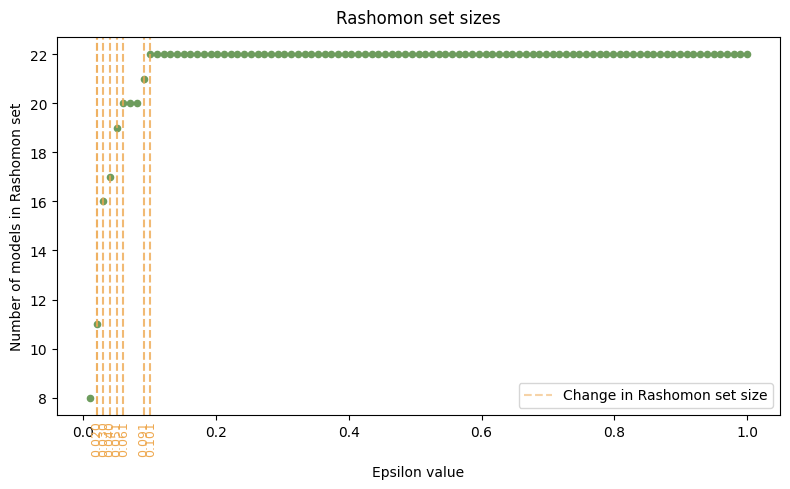

In [5]:
builder.preview_rashomon()

### Set epsilon based on the preview plot

In [6]:
builder.set_epsilon(0.3)

### Launch pipeline  and visualize the dashboard

In [7]:
rashomon_set, visualizer = builder.build()

Building Rashomon Set and Visualizer...
Validating epsilon parameter...
Epsilon parameter set to 0.3.
Rashomon Set and Visualizer built successfully.
Closing all previous Streamlit processes...
Launching Streamlit dashboard...
Streamlit dashboard launched (PID=23260)
You can continue working with your code - to close Streamlit process call dashboard_close() method.


### Work on the Rashomon Set object 

As the dashboard application runs in the background, you are able to continue working on the returned RashomonSet and Visualizer objects.

In [8]:
rashomon_set.get_rashomon_metrics()

{'Base Metric': 'precision',
 'Epsilon': 0.3,
 'Best Score': np.float64(0.9215686274509803),
 'Worst Score All': np.float64(0.8235294117647058),
 'Worst Score Rashomon': np.float64(0.8235294117647058),
 'Worst Model Rashomon': 'DRF_1_AutoML_2_20251028_151348',
 'Base Model': 'StackedEnsemble_AllModels_1_AutoML_2_20251028_151348',
 'Rashomon Set Size': 22,
 'Rashomon Set Models': ['DeepLearning_1_AutoML_2_20251028_151348',
  'DeepLearning_grid_1_AutoML_2_20251028_151348_model_1',
  'DeepLearning_grid_1_AutoML_2_20251028_151348_model_2',
  'DeepLearning_grid_2_AutoML_2_20251028_151348_model_1',
  'DeepLearning_grid_2_AutoML_2_20251028_151348_model_2',
  'DeepLearning_grid_3_AutoML_2_20251028_151348_model_1',
  'DeepLearning_grid_3_AutoML_2_20251028_151348_model_2',
  'DRF_1_AutoML_2_20251028_151348',
  'GBM_1_AutoML_2_20251028_151348',
  'GBM_2_AutoML_2_20251028_151348',
  'GBM_3_AutoML_2_20251028_151348',
  'GBM_4_AutoML_2_20251028_151348',
  'GBM_5_AutoML_2_20251028_151348',
  'GBM_gri

In [9]:
rashomon_set.rashomon_ratio()

1.0

### Remember to close streamlit dashboard after you are finished

To avoid zombie process runnuning in the background, after you are finished with your work, remember to call dashboard_close() which will kill all streamlit processes.

In [10]:
builder.dashboard_close()

🛑 Killing Streamlit (PID=22940)
🛑 Killing Streamlit (PID=23260)


## Build Rashomon Intersection pipeline from H2O input

## Provide all necessary arguments:
all you need to initizalize the pipeline is path to folder with your H2O models and test data as h2o.frame.H2OFrame object

We'll be using the same data as above.

## Build pipeline

In [4]:
builder = BuildRashomonIntersectionH2O(models_directory=example_models_path, 
                           test_data = test_h2o, 
                           target_column=target_column, 
                           df_name = 'heart', 
                           metrics=['accuracy', 'recall'], 
                           weighted_sum_method='critic',
                           feature_imp_needed=True)

Converting H2O models to Rashomon Intersection Analysis format...
Converter results will be stored in: C:\Users\rogal\MojGithub\ARSA-Automated-Rashomon-Set-Analysis\demo_models\h2o\converter_results\heart_2026-01-12_19-37-24
Please wait...
This process may take several minutes depending on the number of models and dataset size.
If you wish to speed up the process, consider setting feature_imp_needed=False.


deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |████████████████████████

Conversion completed.
You can preview the Rashomon Intersection Set size plot using preview_rashomon() method to determine epsilon parameter value.


Model StackedEnsemble_AllModels_1_AutoML_2_20251028_151348 does not have .varimp(). None inserted.
Model StackedEnsemble_BestOfFamily_1_AutoML_2_20251028_151348 does not have .varimp(). None inserted.
H2O conversion results saved to: C:\Users\rogal\MojGithub\ARSA-Automated-Rashomon-Set-Analysis\demo_models\h2o\converter_results\heart_2026-01-12_19-37-24


## Preview Rashomon Intersection properties

The Visualizer received a leaderboard displayed below.
Check if this is the desired leaderboard for analysis, else change the given Path parameter
                                                model  accuracy  \
0             DeepLearning_1_AutoML_2_20251028_151348  0.880435   
1   DeepLearning_grid_1_AutoML_2_20251028_151348_m...  0.907609   
2   DeepLearning_grid_1_AutoML_2_20251028_151348_m...  0.907609   
3   DeepLearning_grid_2_AutoML_2_20251028_151348_m...  0.902174   
4   DeepLearning_grid_2_AutoML_2_20251028_151348_m...  0.853261   
5   DeepLearning_grid_3_AutoML_2_20251028_151348_m...  0.907609   
6   DeepLearning_grid_3_AutoML_2_20251028_151348_m...  0.902174   
7                      DRF_1_AutoML_2_20251028_151348  0.864130   
8                      GBM_1_AutoML_2_20251028_151348  0.896739   
9                      GBM_2_AutoML_2_20251028_151348  0.869565   
10                     GBM_3_AutoML_2_20251028_151348  0.880435   
11                     GBM_4_AutoML_2_20251028_15

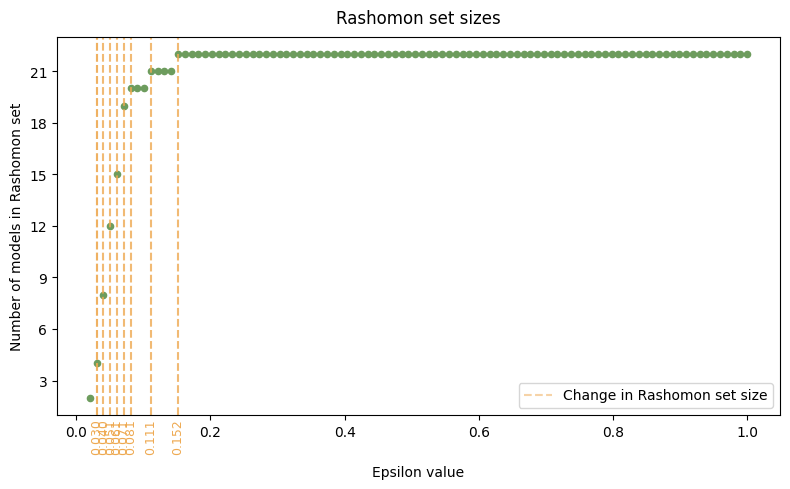

In [5]:
builder.preview_rashomon()

### Set epsilon based on the preview plot

In [6]:
builder.set_epsilon(0.07)

### Launch pipeline  and visualize the dashboard

In [7]:
intersection, intersection_visualizer = builder.build()

Building Rashomon Intersection and Visualizer...
Validating epsilon parameter...
Epsilon parameter set to 0.07.
Rashomon Intersection Set and Visualizer built successfully.
Closing all previous Streamlit processes...
Launching Streamlit dashboard...
Streamlit dashboard launched (PID=62684)
You can continue working with your code - to close Streamlit process call dashboard_close() method.


### Work on the Rashomon Set object 

In [8]:
intersection.summarize_rashomon()


=== Rashomon Intersection Set Summary ===

Selected metrics: accuracy, recall
Determined task type is: binary
Number of classes: 2
Computed weights: 0.49045706835354497, 0.5095429316464549
The size of Rashomon set for given epsilon is: 19.
Base model for given metrics (accuracy, recall) is DeepLearning_grid_1_AutoML_2_20251028_151348_model_2.
There were 0 other models found with the same weighted sum of metrics as base model. These models are: []
Rashomon Ratio metric value is 0.86
Pattern Rashomon Ratio metric value is 0.86
Binary Ambiguity: 0.23
Binary Discrepancy: 0.08
Probabilistic Ambiguity (delta=0.1): 0.74
Probabilistic Discrepancy (delta=0.1): 0.55

Max agreement rate: 1.0

Min agreement rate: 0.2777777777777778

Std agreement rate: 0.12271647251842707


Agreement percents for all models in the Rashomon Intersection: 

DeepLearning_grid_1_AutoML_2_20251028_151348_model_2 : 100.00

DeepLearning_grid_3_AutoML_2_20251028_151348_model_2 : 96.20

GBM_grid_1_AutoML_2_20251028_151348

In [9]:
intersection.base_model

'DeepLearning_grid_1_AutoML_2_20251028_151348_model_2'

### Remember to close streamlit dashboard after you are finished

In [10]:
builder.dashboard_close()

🛑 Killing Streamlit (PID=62684)
🛑 Killing Streamlit (PID=75024)
